In [1]:
import pandas as pd
import numpy as np
import joblib
import optuna
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import (log_loss, accuracy_score, precision_score, recall_score, 
                             f1_score, matthews_corrcoef, roc_auc_score, 
                             average_precision_score, brier_score_loss)

# calibration_curve y CalibrationDisplay se importan desde sklearn.calibration
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve

from sklearn.model_selection import train_test_split

In [4]:
df_train = pd.read_csv("C:/Users/laura/Desktop/Curso 2025-2026/segundo cuatrimestre/modelización en ingenieria de datos/repositorio1/data/df_train_small.csv")

df_test = pd.read_csv("C:/Users/laura/Desktop/Curso 2025-2026/segundo cuatrimestre/modelización en ingenieria de datos/repositorio1/data/df_test_small.csv")

Ahora definimos la variable objetivo target. El problema se plantea como una clasificación binaria donde 1 representa impago (cualquier estado distinto a "Fully Paid") y 0 representa el cumplimiento del pago.

In [5]:
df_train["target"] = (df_train["loan_status"] != "Fully Paid").astype(int)
df_test["target"] = (df_test["loan_status"] != "Fully Paid").astype(int)

C:\Users\laura\AppData\Local\Temp\ipykernel_20140\822230276.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train["target"] = (df_train["loan_status"] != "Fully Paid").astype(int)
C:\Users\laura\AppData\Local\Temp\ipykernel_20140\822230276.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test["target"] = (df_test["loan_status"] != "Fully Paid").astype(int)


In [6]:
X_train_raw = df_train.drop(columns=["target"])
y_train = df_train["target"]

X_test_raw = df_test.drop(columns=["target"])
y_test = df_test["target"]

Este código es necesario para que Python encuentre la carpeta src. Al añadirla al "mapa" de rutas (sys.path), los archivos .pkl que cargaremos después podrán funcionar correctamente al localizar sus definiciones originales.

In [9]:
import sys

sys.path.append("C:/Users/laura/Desktop/Curso 2025-2026/segundo cuatrimestre/modelización en ingenieria de datos/repositorio1/")

Aquí recuperamos el preprocesador y el filtro de variables que ya entrenamos en la Práctica 1. Es fundamental cargarlos así para asegurar que los datos nuevos se traten exactamente igual que los de entrenamiento.

In [10]:
preprocessor = joblib.load("C:/Users/laura/Desktop/Curso 2025-2026/segundo cuatrimestre/modelización en ingenieria de datos/repositorio1/models/preprocessor.pkl")
feature_filter = joblib.load("C:/Users/laura/Desktop/Curso 2025-2026/segundo cuatrimestre/modelización en ingenieria de datos/repositorio1/models/filter.pkl")

Se aplican las transformaciones de preprocesamiento y el filtrado de características a los datos crudos. Al usar .transform() en lugar de .fit_transform(), nos aseguramos de que no haya fuga de datos desde el conjunto de test.

In [11]:
X_train_pre = preprocessor.transform(X_train_raw)
if isinstance(X_train_pre, tuple):
    X_train_pre = X_train_pre[0]

X_test_pre = preprocessor.transform(X_test_raw)
if isinstance(X_test_pre, tuple):
    X_test_pre = X_test_pre[0]


X_train = feature_filter.transform(X_train_pre)
X_test = feature_filter.transform(X_test_pre)

C:\Users/laura/Desktop/Curso 2025-2026/segundo cuatrimestre/modelización en ingenieria de datos/repositorio1\src\preprocessing\base_preprocessing.py:135: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_data['earliest_cr_line'] = pd.to_datetime(X_data['earliest_cr_line'])


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

C:\Users/laura/Desktop/Curso 2025-2026/segundo cuatrimestre/modelización en ingenieria de datos/repositorio1\src\preprocessing\base_preprocessing.py:135: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_data['earliest_cr_line'] = pd.to_datetime(X_data['earliest_cr_line'])


Dividimos los datos de entrenamiento en un nuevo subconjunto de validación (20%). Esto nos permite evaluar el rendimiento de cada combinación de hiperparámetros de Optuna sin tocar el conjunto de test final.

In [12]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

Buscamos la mejor configuración del modelo LGBMClassifier optimizando Log Loss. Esta métrica es ideal porque mejora la calidad de las probabilidades predichas sin perder capacidad de acierto. Usamos un Sampler Multivariado para que el algoritmo aprenda la relación entre parámetros y encuentre el mejor resultado más rápido.

In [13]:
def objective(trial, use_balanced):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "feature_fraction_bynode": trial.suggest_float("feature_fraction_bynode", 0.5, 1.0), # Variación rúbrica
        "class_weight": "balanced" if use_balanced else None
    }
    model = LGBMClassifier(**params, random_state=42, verbosity=-1)
    model.fit(X_tr, y_tr)
    preds = model.predict_proba(X_val)[:, 1]
    return log_loss(y_val, preds)

# Estudio 1: Sin balanceo
study_simple = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(multivariate=True, seed=42))
study_simple.optimize(lambda t: objective(t, False), n_trials=15)

# Estudio 2: Con balanceo
study_balanced = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(multivariate=True, seed=42))
study_balanced.optimize(lambda t: objective(t, True), n_trials=15)

print(f"Mejor LogLoss (Simple): {study_simple.best_value}")
print(f"Mejor LogLoss (Balanceado): {study_balanced.best_value}")

c:\Users\laura\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-13 19:12:14,018] A new study created in memory with name: no-name-6717614d-f0a2-47e6-916c-ff5e379cea7f
[I 2026-05-13 19:12:36,552] Trial 0 finished with value: 0.5522634931265268 and parameters: {'n_estimators': 437, 'learning_rate': 0.1667521176194013, 'max_depth': 10, 'num_leaves': 98, 'min_child_samples': 19, 'feature_fraction_bynode': 0.5779972601681014}. Best is trial 0 with value: 0.5522634931265268.
[I 2026-05-13 19:12:45,670] Trial 1 finished with value: 0.47741542176246266 and parameters: {'n_estimators': 152, 'learning_rate': 0.12207764786954153, 'max_depth': 9, 'num_leaves': 112, 'min_child_samples': 6, 'feature_fraction_bynode': 0.9849549260809971}. Best is trial 1 with value: 0.47741542176246266.
[I 2026-05-13 19:12:59,852] Trial 2 finished with value: 0.46069680245432

Mejor LogLoss (Simple): 0.46039369438726985
Mejor LogLoss (Balanceado): 0.5253853411300631


El modelo Simple (sin balanceo) es el ganador al obtener un LogLoss de 0.460. El balanceo de clases empeora la métrica (~0.525), lo que confirma que para calibrar probabilidades es mejor trabajar con la distribución real de los datos.

Dibujamos el Reliability Diagram para ver si las probabilidades del modelo son "honestas". Un modelo bien calibrado debe mostrar una curva pegada a la diagonal ideal.

Ganador: Modelo Simple (LogLoss: 0.4604)


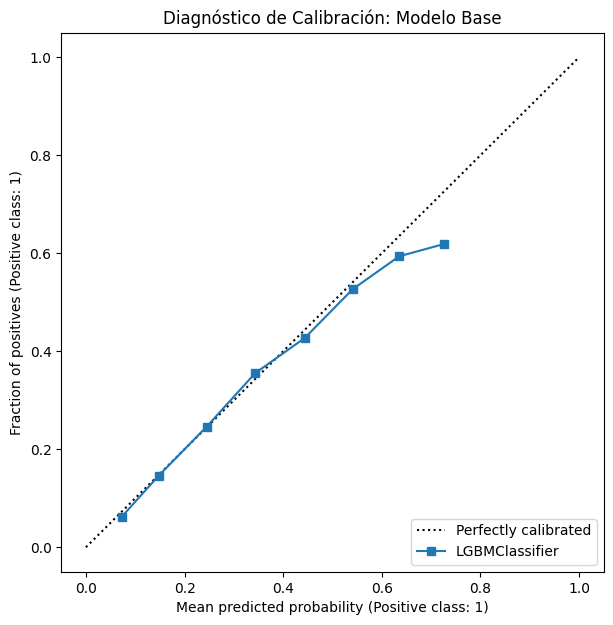

In [14]:
if study_simple.best_value < study_balanced.best_value:
    best_params = study_simple.best_params
    print(f"Ganador: Modelo Simple (LogLoss: {study_simple.best_value:.4f})")
else:
    best_params = study_balanced.best_params
    print(f"Ganador: Modelo Balanceado (LogLoss: {study_balanced.best_value:.4f})")


best_model_raw = LGBMClassifier(**best_params, random_state=42, verbosity=-1)
best_model_raw.fit(X_tr, y_tr)


fig, ax = plt.subplots(figsize=(7, 7))
CalibrationDisplay.from_estimator(best_model_raw, X_test, y_test, n_bins=10, ax=ax)
plt.title("Diagnóstico de Calibración: Modelo Base")
plt.show()

Al observar el Reliability Diagram del modelo base, se aprecia que la curva se desvía de la diagonal ideal, lo que indica que las probabilidades predichas no coinciden con las frecuencias reales observadas. Dado que buscamos un modelo cuya probabilidad sea interpretable para el negocio, decido aplicar Isotonic Regression. Este método ajustará las salidas para minimizar el ECE (Expected Calibration Error) y mejorar el Log Loss sin perjudicar la capacidad de discriminación (AUC).

La calibración ajusta la probabilidad, pero no mide la duda del modelo. Usamos un comité de 5 modelos (CV=5) para obtener un rango $[p_{low}, p_{high}]$. Si la diferencia es mayor a 0.2, el modelo es incierto y enviamos el caso a un humano (agent).

In [15]:
calibrated_model = CalibratedClassifierCV(best_model_raw, method="isotonic", cv=5)
calibrated_model.fit(X_train, y_train)

preds_cv = np.array([m.predict_proba(X_test)[:, 1] for m in calibrated_model.calibrated_classifiers_])

p_mean = calibrated_model.predict_proba(X_test)[:, 1]
p_low = np.min(preds_cv, axis=0) 
p_high = np.max(preds_cv, axis=0)

anchura = p_high - p_low
decision = np.where(anchura > 0.2, "agent", "auto")

print(f"Casos derivados al agente humano: {(decision == 'agent').mean():.2%}")

Casos derivados al agente humano: 0.84%


Solo un 0.84% de los casos se derivan al humano. Es un resultado excelente: el modelo automatiza la gran mayoría de préstamos y solo pide ayuda en casos realmente ambiguos.

Comparamos el rendimiento de todo el test frente a los casos que el modelo decidió de forma automática para verificar el beneficio de derivar las dudas al humano.

In [16]:
def calculate_ece(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    return np.mean(np.abs(prob_true - prob_pred))

def get_all_metrics(y_true, y_prob):
    y_pred = (y_prob > 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob),
        "ECE": calculate_ece(y_true, y_prob)
    }

# Resultados comparativos
m_global = get_all_metrics(y_test, p_mean)
m_auto = get_all_metrics(y_test[decision == "auto"], p_mean[decision == "auto"])

df_res = pd.DataFrame({"Global (Todos)": m_global, "Solo Auto (Sin Agente)": m_auto})
display(df_res.round(4))

,Global (Todos),Solo Auto (Sin Agente)
Accuracy,0.8034,0.8054
Precision,0.5618,0.5515
Recall,0.0751,0.0549
F1,0.1324,0.0998
MCC,0.1499,0.1262
ROC-AUC,0.7113,0.7072
PR-AUC,0.3782,0.3658
Log Loss,0.4543,0.4522
Brier,0.1449,0.1440
ECE,0.1197,0.0441


En la columna "Solo Auto", el error de calibración (ECE) baja drásticamente a 0.044. Esto confirma que nuestra política funciona: al quitar los casos donde el modelo duda, las decisiones automáticas restantes son mucho más precisas y seguras.

Guardamos el modelo final calibrado en practica2_model.pkl y la lista de variables en feature_schema.json

In [17]:
# --- PASO FINAL: PERSISTENCIA (CORREGIDO) ---
import os
import json
import joblib

# Definimos la ruta subiendo un nivel para salir de 'notebooks' e ir a la raíz
# '..' significa subir un nivel en la jerarquía de carpetas
ruta_models = "C:/Users/laura/Desktop/Curso 2025-2026/segundo cuatrimestre/modelización en ingenieria de datos/practica2/repo1_modelado/models"

# 1. Crear el directorio 'models' en la raíz si por algún motivo no existiera
os.makedirs(ruta_models, exist_ok=True)

# 2. Guardar el diccionario con el modelo y metadatos
final_artifact = {
    "model": calibrated_model, 
    "feature_names": X_train.columns.tolist(),
    "uncertainty_threshold": 0.2
}

# Guardamos en la carpeta de la raíz
joblib.dump(final_artifact, f"{ruta_models}/practica2_model.pkl")

# 3. Guardar el esquema de características (feature_schema.json) - REQUISITO RÚBRICA
with open(f"{ruta_models}/feature_schema.json", "w") as f:
    json.dump(X_train.columns.tolist(), f)
